# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel

import glob
import clip
import os

In [2]:
# CARGAR MODELO CLIP
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
# 1. CARGAR IMÁGENES
CARPETA_IMAGENES = r"C:\Users\DELL\Downloads\Septimo2025\RI\RI1"

rutas_imagenes = sorted(glob.glob(os.path.join(CARPETA_IMAGENES, "*.jpg")))
imagenes = [Image.open(ruta).convert("RGB") for ruta in rutas_imagenes]

print(f"Imágenes cargadas: {len(imagenes)}")

Imágenes cargadas: 18


In [4]:
# 2. PREPROCESAR IMÁGENES PARA CLIP
imagenes = [
    Image.open(p).convert("RGB")
    for p in rutas_imagenes
]

In [5]:
# 3. OBTENER EMBEDDINGS DE IMÁGENES
inputs = processor(images=imagenes, return_tensors="pt")

with torch.no_grad():
    emb_imagenes = model.get_image_features(**inputs)

# Normalizar embeddings (norma = 1)
emb_imagenes = emb_imagenes / emb_imagenes.norm(dim=-1, keepdim=True)

# Pasar a numpy (para PCA, t-SNE, cosine similarity)
emb_imagenes = emb_imagenes.numpy()

print("Embeddings de imágenes:", emb_imagenes.shape)

Embeddings de imágenes: (18, 512)


In [6]:
texts = [
    "dog",
    "cat",
    "car",
    "bike",
    "person ",
    "bed"
]

inputs = processor(text=texts, return_tensors="pt", padding=True)

with torch.no_grad():
    emb_textos = model.get_text_features(**inputs)

# Normalizar embeddings
emb_textos = emb_textos / emb_textos.norm(dim=-1, keepdim=True)

# Pasar a numpy (para PCA, t-SNE, cosine similarity)
emb_textos = emb_textos.numpy()

print("Embeddings de texto:", emb_textos.shape)

Embeddings de texto: (6, 512)


In [7]:
print("Dimensión imagen:", emb_imagenes.shape[1])
print("Dimensión texto:", emb_textos.shape[1])

Dimensión imagen: 512
Dimensión texto: 512


In [8]:
similarity = cosine_similarity(
    emb_textos,
    emb_imagenes
)

similarity

array([[0.19296631, 0.22686742, 0.18654227, 0.17809463, 0.17171803,
        0.18318182, 0.16349553, 0.1832875 , 0.17851922, 0.21602184,
        0.21728195, 0.24977767, 0.29187065, 0.27686745, 0.27187836,
        0.20105493, 0.19198067, 0.1936107 ],
       [0.18440253, 0.21499121, 0.18517599, 0.16118492, 0.16315225,
        0.1728233 , 0.16054976, 0.18380858, 0.1699038 , 0.2659288 ,
        0.26414   , 0.29421386, 0.20503041, 0.19408539, 0.1973209 ,
        0.18055792, 0.1880957 , 0.19404912],
       [0.17652486, 0.20178735, 0.25472683, 0.20579696, 0.19831806,
        0.2193074 , 0.25662115, 0.25900853, 0.2586984 , 0.19240808,
        0.18944912, 0.22965384, 0.20660886, 0.19413711, 0.19237725,
        0.2011159 , 0.2051864 , 0.19956066],
       [0.14287211, 0.17764753, 0.17760298, 0.26596394, 0.2597845 ,
        0.27158022, 0.15460373, 0.17243701, 0.17654474, 0.16605043,
        0.16900128, 0.20695803, 0.1841999 , 0.17044438, 0.17104024,
        0.17636149, 0.19634706, 0.17156777],
    

In [9]:
# UNIR EMBEDDINGS (imagen + texto)
all_embeddings = np.vstack([emb_imagenes, emb_textos])

# PCA 2D
pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(all_embeddings)

img_2d_pca = embeddings_2d_pca[:len(emb_imagenes)]
txt_2d_pca = embeddings_2d_pca[len(emb_imagenes):]

# t-SNE 2D
tsne = TSNE(n_components=2, perplexity=12, random_state=42)
embeddings_2d_tsne = tsne.fit_transform(all_embeddings)

img_2d_tsne = embeddings_2d_tsne[:len(emb_imagenes)]
txt_2d_tsne = embeddings_2d_tsne[len(emb_imagenes):]

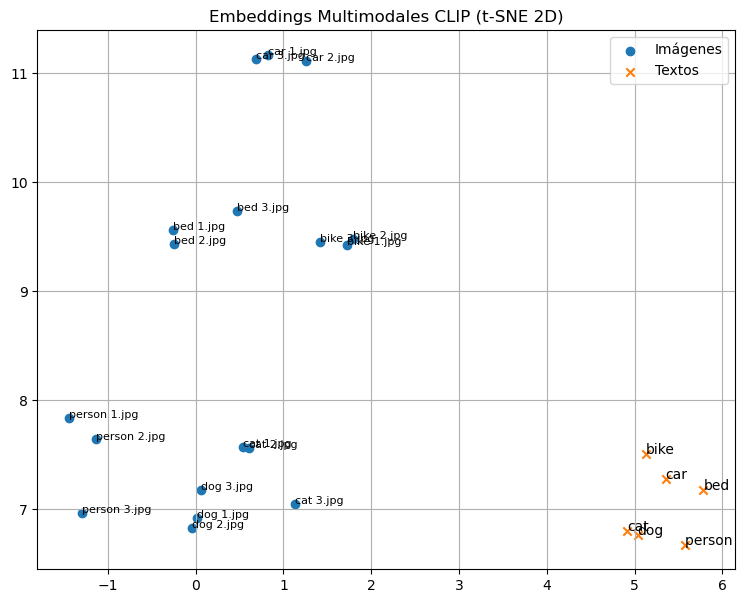

In [10]:
plt.figure(figsize=(9,7))

plt.scatter(img_2d_tsne[:, 0], img_2d_tsne[:, 1], marker='o', label='Imágenes')
for i, name in enumerate(rutas_imagenes):
    plt.text(
        img_2d_tsne[i, 0],
        img_2d_tsne[i, 1],
        os.path.basename(name),
        fontsize=8
    )

plt.scatter(txt_2d_tsne[:, 0], txt_2d_tsne[:, 1], marker='x', label='Textos')
for i, txt in enumerate(texts):
    plt.text(
        txt_2d_tsne[i, 0],
        txt_2d_tsne[i, 1],
        txt,
        fontsize=10
    )

plt.title("Embeddings Multimodales CLIP (t-SNE 2D)")
plt.legend()
plt.grid(True)
plt.show()


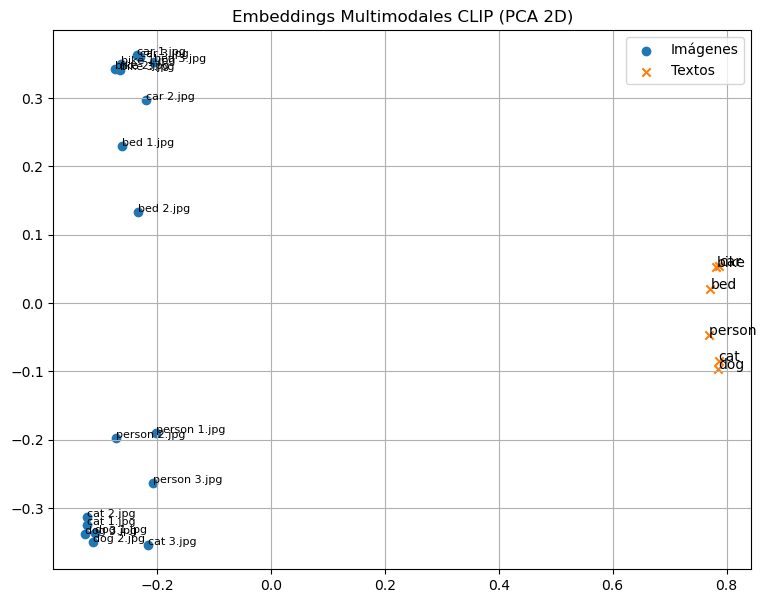

In [11]:
plt.figure(figsize=(9,7))

plt.scatter(img_2d_pca[:, 0], img_2d_pca[:, 1], marker='o', label='Imágenes')
for i, name in enumerate(rutas_imagenes):
    plt.text(
        img_2d_pca[i, 0],
        img_2d_pca[i, 1],
        os.path.basename(name),
        fontsize=8
    )

plt.scatter(txt_2d_pca[:, 0], txt_2d_pca[:, 1], marker='x', label='Textos')
for i, txt in enumerate(texts):
    plt.text(
        txt_2d_pca[i, 0],
        txt_2d_pca[i, 1],
        txt,
        fontsize=10
    )

plt.title("Embeddings Multimodales CLIP (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
def buscar_imagen(texto):
    # Embedding del texto
    inputs = processor(text=[texto], return_tensors="pt", padding=True)
    with torch.no_grad():
        emb_texto = model.get_text_features(**inputs)

    # Normalizar
    emb_texto = emb_texto / emb_texto.norm(dim=-1, keepdim=True)
    emb_texto = emb_texto.numpy()

    # Similaridad coseno texto → imágenes
    scores = cosine_similarity(
        emb_texto,
        emb_imagenes
    )[0]

    idx = np.argmax(scores)

    print("Texto:", texto)
    print("Imagen más similar:", os.path.basename(rutas_imagenes[idx]))
    print("Score:", scores[idx])

    # Mostrar imagen
    img = Image.open(rutas_imagenes[idx])
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [13]:
def buscar_texto(nombre_imagen):
    # Cargar imagen
    image = Image.open(nombre_imagen).convert("RGB")

    # Embedding de la imagen
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        emb_imagen = model.get_image_features(**inputs)

    # Normalizar
    emb_imagen = emb_imagen / emb_imagen.norm(dim=-1, keepdim=True)
    emb_imagen = emb_imagen.numpy()

    # Similaridad coseno imagen → textos
    scores = cosine_similarity(
        emb_imagen,
        emb_textos
    )[0]

    # Mostrar scores ordenados
    text_scores = sorted(zip(texts, scores), key=lambda x: x[1], reverse=True)
    print("Scores texto:")
    for t, s in text_scores:
        print(f"{t:35s} -> {s:.4f}")

    idx = np.argmax(scores)

    print("\nImagen:", os.path.basename(nombre_imagen))
    print("Texto más cercano:", texts[idx])

    plt.imshow(image)
    plt.axis("off")
    plt.show()


Texto: person 3
Imagen más similar: person 3.jpg
Score: 0.24229297


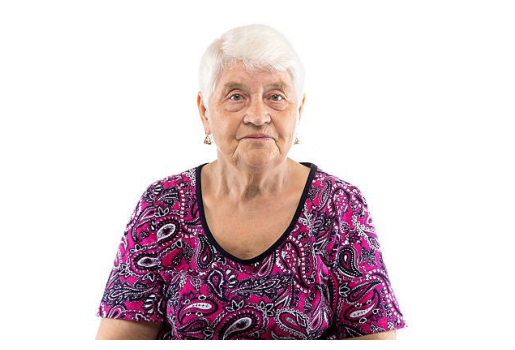

In [14]:
buscar_imagen("person 3")

Scores texto:
person                              -> 0.2286
car                                 -> 0.2011
dog                                 -> 0.2011
bed                                 -> 0.1889
cat                                 -> 0.1806
bike                                -> 0.1764

Imagen: person 1.jpg
Texto más cercano: person 


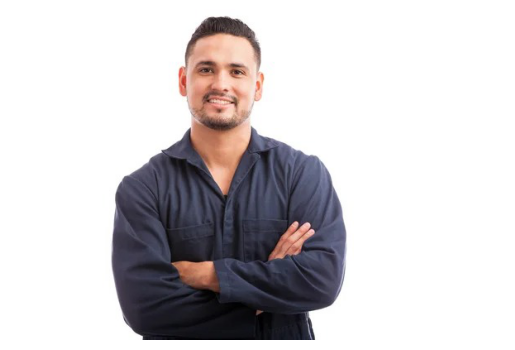

In [15]:
buscar_texto(r"C:\Users\DELL\Downloads\Septimo2025\RI\RI1/person 1.jpg")